In [2]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir(r"D:\proj-python\Images_Vision")

shape of image (365, 547, 3)


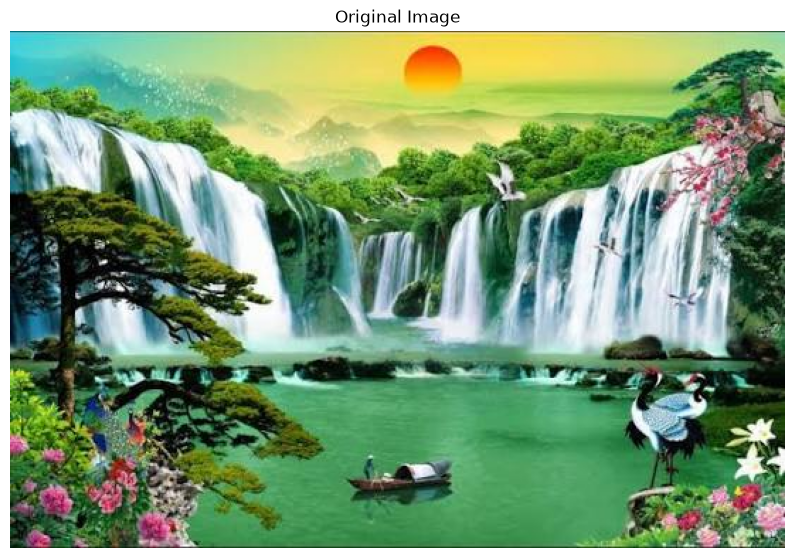

In [3]:
img=cv2.imread("scenery.png")
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
print("shape of image",img.shape)
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.title("Original Image")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


shape of pixel values (199655, 3)


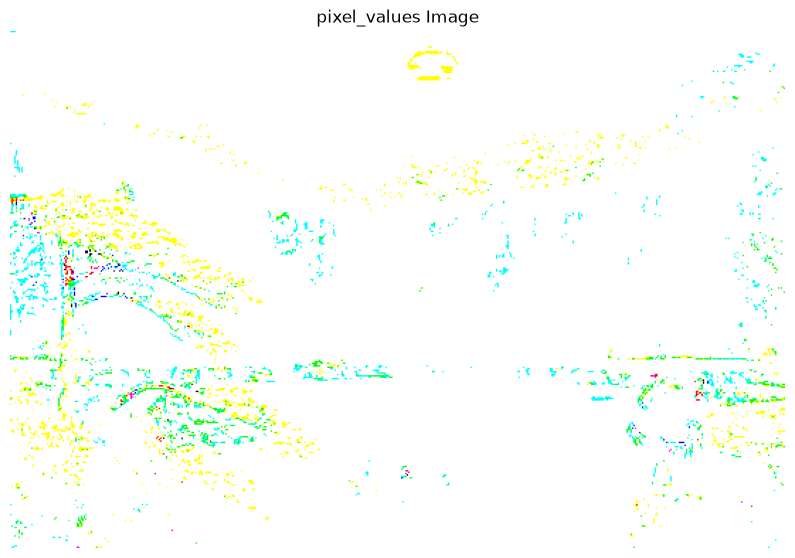

In [4]:
pixel_values=img.reshape((-1,3))
pixel_values=np.float32(pixel_values)
print("shape of pixel values",pixel_values.shape)
plt.figure(figsize=(10,10))
plt.imshow(pixel_values.reshape(img.shape))
plt.axis("off")
plt.title("pixel_values Image")
plt.show()

In [6]:
k=5
criteria=(cv2.TERM_CRITERIA_EPS+cv2.TERM_CRITERIA_MAX_ITER,100,0.95)
clusters,labels,centers=cv2.kmeans(pixel_values,k,None,criteria,10,cv2.KMEANS_RANDOM_CENTERS)
print(clusters)
print(labels)
print(centers)

386632355.25101525
[[4]
 [4]
 [4]
 ...
 [0]
 [0]
 [0]]
[[ 29.355148  56.109108  27.990541]
 [215.03915  228.75568  230.24208 ]
 [211.41158  212.09195  105.64463 ]
 [133.75656  177.58969  160.6002  ]
 [ 80.74515  137.17001   83.870346]]


centers [[ 29  55  27]
 [ 80 137  83]
 [211 212 105]
 [214 228 230]
 [133 177 160]]
labels [0 1 2 3 4]


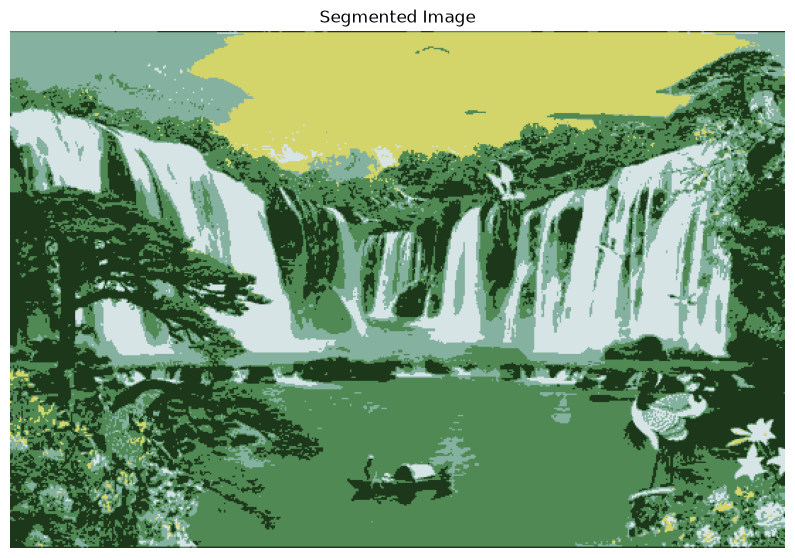

In [ ]:
centers=np.uint8(centers)
print("centers",centers)

labels=labels.flatten()
print("labels",np.unique(labels))

segmented_image=centers[labels]
segmented_image=segmented_image.reshape(img.shape)

plt.figure(figsize=(10,10))
plt.imshow(segmented_image)
plt.axis("off")
plt.title("Segmented Image")
plt.show()

# Rmove specific cluster

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


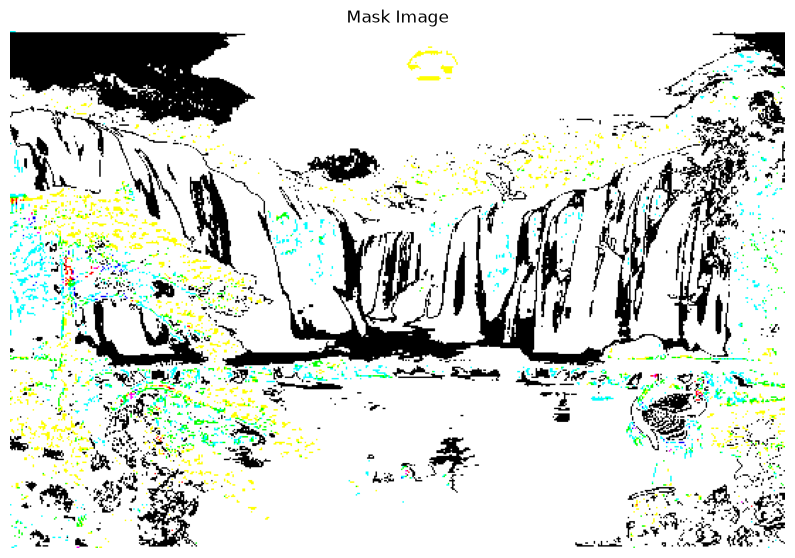

In [ ]:
k=5
mask_img=img.copy()
mask_img=mask_img.reshape((-1,3))
mask_img=np.float32(mask_img)
_,labels,__=cv2.kmeans(mask_img,k,None,criteria,10,cv2.KMEANS_RANDOM_CENTERS)
labels=labels.flatten()
cluster_labels=np.unique(labels)
# mask_img=np.uint8(mask_img)
mask_img[labels==cluster_labels[3]]=[0,0,0]
mask_img=mask_img.reshape(img.shape)
plt.figure(figsize=(10,10))
plt.imshow(mask_img)
plt.axis("off")
plt.title("Mask Image")
plt.show()
